# t-SNE: Interactive Exploration Notebook
## t-Distributed Stochastic Neighbor Embedding

**Course:** TTK4260 — Multivariate Data Analysis and Machine Learning
**Author:** Prof. Adil Rasheed, NTNU Department of Engineering Cybernetics

---

This notebook is a companion to the t-SNE lecture slides. Each section pairs a brief
explanation with **interactive visualizations** so you can build intuition by
manipulating data and parameters yourself.

### How to use this notebook
- Run all cells in order (the setup cell must run first)
- **Interact** with sliders, dropdowns, and toggles to explore each concept
- Read the markdown explanations — they mirror the lecture slides

### Sections
1. Motivation and where t-SNE fits
2. The t-SNE objective in plain language
3. Perplexity, kernels, and the crowding problem
4. Optimization details (just enough)
5. How to use t-SNE in practice
6. Interpretation & common pitfalls
7. Alternatives and wrap-up


In [41]:

# ═══════════════════════════════════════════════════
# SETUP — Run this cell first!
# ═══════════════════════════════════════════════════
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import plotly.graph_objects as go
import plotly.express as px

from sklearn.manifold import TSNE, MDS
from sklearn.decomposition import PCA
from sklearn.datasets import (make_swiss_roll, make_blobs, make_moons,
                               make_s_curve, load_digits)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import pdist, squareform

from ipywidgets import interact, widgets
from IPython.display import display, HTML
import time

# ── Consistent color palette (matches lecture slides) ──
COLORS = {
    "A": "#E74C3C", "B": "#2E86C1", "C": "#27AE60",
    "D": "#F39C12", "ntnu": "#00509E", "gray": "#AAAAAA",
}
CLUSTER_CMAP = ListedColormap([COLORS["A"], COLORS["B"], COLORS["C"], COLORS["D"]])
CONTINUOUS_CMAP = "Spectral"
RNG = np.random.RandomState(42)


def make_dataset(name="swiss_roll", n=500, noise=0.5, random_state=42):
    """Generate a synthetic dataset for demos."""
    if name == "swiss_roll":
        X, color = make_swiss_roll(n_samples=n, noise=noise, random_state=random_state)
        return X, color, "Swiss Roll"
    elif name == "blobs":
        X, labels = make_blobs(n_samples=n, centers=4, n_features=10,
                               cluster_std=1.5, random_state=random_state)
        return X, labels, "4 Gaussian Blobs (10D)"
    elif name == "moons":
        X, labels = make_moons(n_samples=n, noise=0.08, random_state=random_state)
        X_hd = np.hstack([X, RNG.randn(n, 8) * 0.3])
        return X_hd, labels, "Two Moons (10D)"
    elif name == "s_curve":
        X, color = make_s_curve(n_samples=n, noise=noise, random_state=random_state)
        return X, color, "S-Curve"
    elif name == "concentric":
        theta = RNG.uniform(0, 2 * np.pi, n)
        phi = RNG.uniform(0, np.pi, n)
        labels = (np.arange(n) > n // 2).astype(int)
        r = np.where(labels == 0, 1.0, 3.0) + RNG.randn(n) * 0.15
        X = np.column_stack([r * np.sin(phi) * np.cos(theta),
                             r * np.sin(phi) * np.sin(theta),
                             r * np.cos(phi)])
        return X, labels, "Concentric Spheres (3D)"


def run_tsne(X, perplexity=30, lr=200, n_iter=1000, init="random", seed=42, early_exag=12.0):
    """Run t-SNE with given parameters."""
    tsne = TSNE(n_components=2, perplexity=min(perplexity, len(X) - 1),
                learning_rate=lr if lr != "auto" else "auto",
                max_iter=n_iter, init=init, random_state=seed,
                early_exaggeration=early_exag)
    return tsne.fit_transform(X)


print("\u2713 Setup complete. All packages loaded.")


✓ Setup complete. All packages loaded.


---
# Section 1 — Motivation and Where t-SNE Fits

| Method | Type | Preserves |
|--------|------|-----------|
| MLR | Supervised, linear | Predictive relationship |
| PCA / PCR | Unsupervised, linear | Global variance |
| PLSR | Supervised, linear | Covariance with response |
| **t-SNE** | **Unsupervised, nonlinear** | **Local neighborhoods** |

Real datasets often live on **curved manifolds**. Linear projections (PCA) preserve
global variance but can **mix up local neighborhoods**. t-SNE produces a 2D map
where **who is near whom** is faithfully represented.

👇 Toggle between datasets and see how PCA handles (or fails) nonlinear structure.


In [42]:
# ── Section 1: PCA vs Nonlinear Structure ──

def demo_pca_vs_structure(dataset="swiss_roll", n_points=600):
    X, color, title = make_dataset(dataset, n=n_points)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    is_continuous = not np.array_equal(color, color.astype(int))
    cmap = CONTINUOUS_CMAP if is_continuous else CLUSTER_CMAP
    vmin, vmax = (color.min(), color.max()) if is_continuous else (None, None)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if X.shape[1] == 3:
        axes[0].scatter(X[:, 0], X[:, 2], c=color, cmap=cmap, s=12, alpha=0.7,
                        vmin=vmin, vmax=vmax, edgecolors="none")
        axes[0].set_title(f"{title} (dims 1 & 3)", fontweight="bold")
    else:
        axes[0].scatter(X[:, 0], X[:, 1], c=color, cmap=cmap, s=12, alpha=0.7,
                        vmin=vmin, vmax=vmax, edgecolors="none")
        axes[0].set_title(f"{title} (first 2 of {X.shape[1]}D)", fontweight="bold")

    var_expl = pca.explained_variance_ratio_[:2].sum() * 100
    axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=color, cmap=cmap, s=12, alpha=0.7,
                    vmin=vmin, vmax=vmax, edgecolors="none")
    axes[1].set_title(f"PCA (2D) — {var_expl:.1f}% variance", fontweight="bold")

    for ax in axes:
        ax.set_aspect("equal", adjustable="datalim")
        ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    if dataset in ["swiss_roll", "s_curve"]:
        print("\u26A0  PCA MIXES the colors — nearby manifold points end up far apart!")
    elif dataset == "blobs":
        print("\u2713  For well-separated blobs, PCA works fine. t-SNE shines on nonlinear data.")

interact(demo_pca_vs_structure,
         dataset=widgets.Dropdown(
             options=["swiss_roll", "s_curve", "blobs", "moons", "concentric"],
             value="swiss_roll", description="Dataset:"),
         n_points=widgets.IntSlider(min=200, max=1200, step=100, value=600,
                                    description="N points:"))


interactive(children=(Dropdown(description='Dataset:', options=('swiss_roll', 's_curve', 'blobs', 'moons', 'co…

<function __main__.demo_pca_vs_structure(dataset='swiss_roll', n_points=600)>

---
# Section 2 — The t-SNE Objective in Plain Language

## The three-step pipeline

1. **High-D → similarities $p_{ij}$:** Gaussian kernel with per-point bandwidth $\sigma_i$
2. **Low-D → similarities $q_{ij}$:** Student-t (Cauchy) kernel
3. **Minimize KL divergence:** $\mathcal{L} = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$

**Key formulas:**
$$p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}, \quad p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}$$

$$q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\sum_{k \neq l}(1 + \|y_k - y_l\|^2)^{-1}}$$

👇 Visualize the similarity matrices for a small dataset.


In [43]:
# ── Section 2: Visualize the pipeline on a small dataset ──

def compute_pij(X, perplexity=10):
    """Compute symmetric p_ij matrix."""
    n = X.shape[0]
    distances = squareform(pdist(X, "sqeuclidean"))
    P = np.zeros((n, n))
    target_entropy = np.log2(perplexity)

    for i in range(n):
        lo, hi = 1e-10, 1e4
        dists_i = distances[i].copy()
        dists_i[i] = np.inf
        for _ in range(50):
            sigma = (lo + hi) / 2.0
            pji = np.exp(-dists_i / (2 * sigma ** 2))
            pji[i] = 0
            pji_sum = pji.sum()
            if pji_sum < 1e-12:
                lo = sigma
                continue
            pji /= pji_sum
            entropy = -np.sum(pji[pji > 0] * np.log2(pji[pji > 0]))
            if entropy > target_entropy:
                hi = sigma
            else:
                lo = sigma
        P[i] = pji

    P = (P + P.T) / (2 * n)
    np.fill_diagonal(P, 0)
    return np.maximum(P, 1e-12)


def compute_qij(Y):
    """Compute q_ij from low-D embedding (Student-t kernel)."""
    distances = squareform(pdist(Y, "sqeuclidean"))
    Q = 1.0 / (1.0 + distances)
    np.fill_diagonal(Q, 0)
    Q /= Q.sum()
    return np.maximum(Q, 1e-12)


def demo_pipeline(perplexity=5):
    np.random.seed(42)
    centers = np.array([[0, 0, 0], [3, 3, 3], [6, 0, 0]])
    X = np.vstack([c + np.random.randn(5, 3) * 0.5 for c in centers])
    labels = np.repeat([0, 1, 2], 5)

    P = compute_pij(X, perplexity=perplexity)
    Y = run_tsne(X, perplexity=perplexity, seed=42)
    Q = compute_qij(Y)
    KL = P * np.log(P / Q)
    np.fill_diagonal(KL, 0)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    D = squareform(pdist(X))

    for ax, mat, cmap_name, title in zip(axes,
            [D, P, Q, KL],
            ["viridis", "hot", "hot", "Reds"],
            ["Pairwise Distances\n(High-D)",
             f"$p_{{ij}}$ (High-D)\nPerp={perplexity}",
             "$q_{ij}$ (Low-D)\nStudent-t",
             f"KL contributions\nTotal={KL.sum():.3f}"]):
        im = ax.imshow(mat, cmap=cmap_name, aspect="equal")
        ax.set_title(title, fontweight="bold", fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.046)
        for b in [5, 10]:
            ax.axhline(b - 0.5, color="white", lw=0.8, alpha=0.5)
            ax.axvline(b - 0.5, color="white", lw=0.8, alpha=0.5)

    plt.tight_layout()
    plt.show()

    # Show embedding
    fig2, ax2 = plt.subplots(figsize=(5, 4))
    for c, col, nm in [(0, COLORS["A"], "A"), (1, COLORS["B"], "B"), (2, COLORS["C"], "C")]:
        mask = labels == c
        ax2.scatter(Y[mask, 0], Y[mask, 1], c=col, s=60, label=f"Cluster {nm}",
                    edgecolors="white", linewidth=0.5, zorder=3)
        for idx in np.where(mask)[0]:
            ax2.annotate(str(idx), (Y[idx, 0], Y[idx, 1]), fontsize=7,
                         ha="center", va="center", color="white", fontweight="bold")
    ax2.set_title("t-SNE Embedding", fontweight="bold")
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.2)
    ax2.set_aspect("equal", adjustable="datalim")
    plt.tight_layout()
    plt.show()

    print("The KL matrix shows WHERE the cost concentrates:")
    print("  Bright cells = true neighbors placed too far apart in the embedding.")

interact(demo_pipeline,
         perplexity=widgets.IntSlider(min=2, max=14, step=1, value=5,
                                      description="Perplexity:"))


interactive(children=(IntSlider(value=5, description='Perplexity:', max=14, min=2), Output()), _dom_classes=('…

<function __main__.demo_pipeline(perplexity=5)>

---
# Section 3 — Perplexity, Kernels, and the Crowding Problem

## Perplexity = "effective number of neighbors"

$$\text{Perp}(P_i) = 2^{H(P_i)}, \quad H(P_i) = -\sum_j p_{j|i} \log_2 p_{j|i}$$

| Low perplexity | High perplexity |
|----------------|-----------------|
| Very local view — may fragment clusters | Broader neighborhoods — may merge structure |
| Typical: 5–10 | Typical: 30–50 |

👇 Sweep perplexity and watch the effect.


In [44]:
# ── Section 3a: Perplexity Sweep ──

X_perp, labels_perp, _ = make_dataset("blobs", n=400, random_state=42)
X_perp = StandardScaler().fit_transform(X_perp)

print("Pre-computing t-SNE at multiple perplexities...")
perp_values = [2, 5, 10, 20, 30, 50, 80, 100]
embeddings_perp = {}
for p in perp_values:
    embeddings_perp[p] = run_tsne(X_perp, perplexity=p, seed=42)
print("Done!")


def demo_perplexity(perplexity=30):
    Y = embeddings_perp[perplexity]
    fig, ax = plt.subplots(figsize=(7, 6))
    for c, col in enumerate([COLORS["A"], COLORS["B"], COLORS["C"], COLORS["D"]]):
        mask = labels_perp == c
        ax.scatter(Y[mask, 0], Y[mask, 1], c=col, s=25, alpha=0.8,
                   edgecolors="white", linewidth=0.3, label=f"Cluster {c+1}")
    ax.set_title(f"t-SNE with Perplexity = {perplexity}", fontsize=14, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.15)
    ax.set_aspect("equal", adjustable="datalim")
    plt.tight_layout()
    plt.show()

    if perplexity <= 5:
        print("Low perplexity: very local — clusters may fragment.")
    elif perplexity >= 80:
        print("High perplexity: very broad — structure may merge.")
    else:
        print(f"Perplexity {perplexity}: reasonable for this dataset.")

interact(demo_perplexity,
         perplexity=widgets.SelectionSlider(options=perp_values, value=30,
                                            description="Perplexity:"))


Pre-computing t-SNE at multiple perplexities...
Done!


interactive(children=(SelectionSlider(description='Perplexity:', index=4, options=(2, 5, 10, 20, 30, 50, 80, 1…

<function __main__.demo_perplexity(perplexity=30)>

In [45]:
# ── Section 3b: Gaussian vs Student-t Kernel ──

def demo_kernels(df=1):
    d = np.linspace(0, 6, 300)
    gaussian = np.exp(-d ** 2 / 2)
    student_t = (1 + d ** 2 / df) ** (-(df + 1) / 2)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(d, gaussian, color=COLORS["A"], lw=2.5, ls="--", label="Gaussian")
    axes[0].plot(d, student_t, color=COLORS["ntnu"], lw=2.5, label=f"Student-t (df={df})")
    axes[0].fill_between(d, student_t, gaussian, where=student_t > gaussian,
                         alpha=0.15, color=COLORS["C"])
    axes[0].set_title("Linear scale", fontweight="bold")
    axes[0].set_xlabel("Distance d"); axes[0].set_ylabel("Kernel weight")
    axes[0].legend(fontsize=11); axes[0].grid(True, alpha=0.2)

    axes[1].semilogy(d, gaussian, color=COLORS["A"], lw=2.5, ls="--", label="Gaussian")
    axes[1].semilogy(d, student_t, color=COLORS["ntnu"], lw=2.5, label=f"Student-t (df={df})")
    axes[1].set_title("Log scale (tail difference visible!)", fontweight="bold")
    axes[1].set_xlabel("Distance d"); axes[1].set_ylabel("Kernel weight (log)")
    axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.2)
    axes[1].set_ylim(1e-10, 2)

    plt.suptitle("Gaussian vs Student-t Kernel", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print("At large distances, the Student-t assigns MUCH more weight than the Gaussian.")
    print("This heavy tail provides room to push dissimilar points further apart.")

interact(demo_kernels,
         df=widgets.IntSlider(min=1, max=20, step=1, value=1, description="Degrees of freedom:"))


interactive(children=(IntSlider(value=1, description='Degrees of freedom:', max=20, min=1), Output()), _dom_cl…

<function __main__.demo_kernels(df=1)>

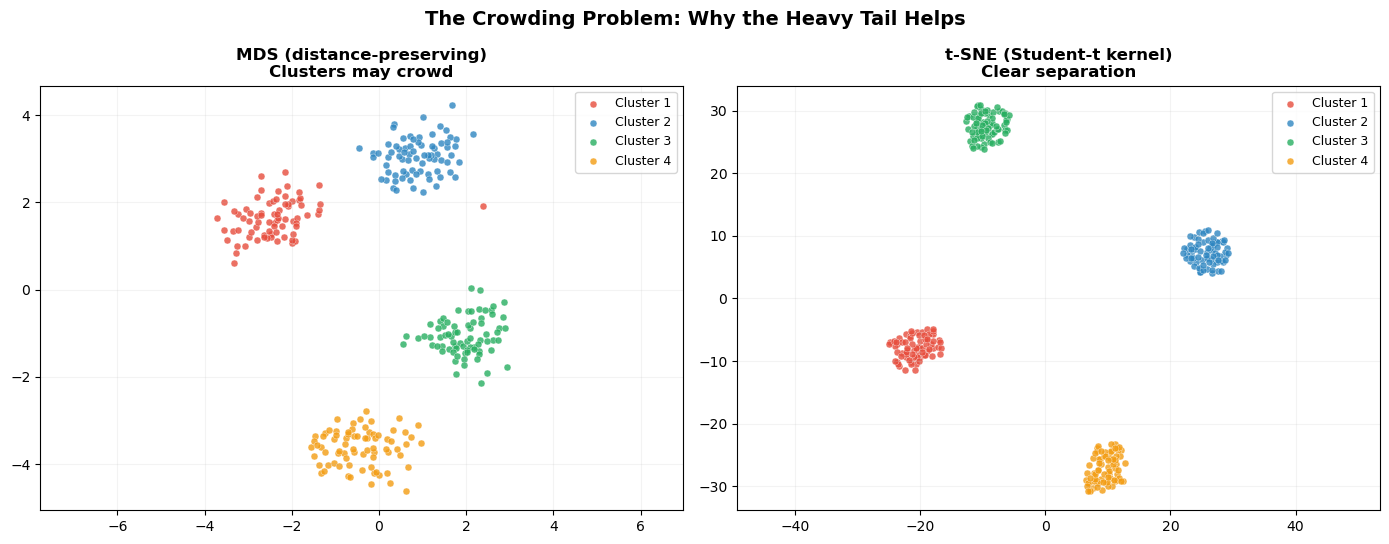

In [46]:
# ── Section 3c: Crowding Problem Demo ──

X_crowd, labels_crowd, _ = make_dataset("blobs", n=300, random_state=42)
X_crowd = StandardScaler().fit_transform(X_crowd)

Y_tsne_c = run_tsne(X_crowd, perplexity=30, seed=42)
mds = MDS(n_components=2, random_state=42, normalized_stress="auto")
Y_mds_c = mds.fit_transform(X_crowd)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for c, col in enumerate([COLORS["A"], COLORS["B"], COLORS["C"], COLORS["D"]]):
    mask = labels_crowd == c
    axes[0].scatter(Y_mds_c[mask, 0], Y_mds_c[mask, 1], c=col, s=25, alpha=0.8,
                    edgecolors="white", linewidth=0.3, label=f"Cluster {c+1}")
    axes[1].scatter(Y_tsne_c[mask, 0], Y_tsne_c[mask, 1], c=col, s=25, alpha=0.8,
                    edgecolors="white", linewidth=0.3, label=f"Cluster {c+1}")

axes[0].set_title("MDS (distance-preserving)\nClusters may crowd", fontweight="bold")
axes[1].set_title("t-SNE (Student-t kernel)\nClear separation", fontweight="bold")
for ax in axes:
    ax.legend(fontsize=9); ax.grid(True, alpha=0.15)
    ax.set_aspect("equal", adjustable="datalim")
plt.suptitle("The Crowding Problem: Why the Heavy Tail Helps", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


---
# Section 4 — Optimization Details

## Asymmetry of KL divergence

- Missing a **true neighbor** (large $p_{ij}$, small $q_{ij}$) → **BIG penalty**
- Adding a **spurious neighbor** (small $p_{ij}$, larger $q_{ij}$) → smaller penalty

## Gradient: $\frac{\partial \mathcal{L}}{\partial y_i} \propto \sum_j (p_{ij} - q_{ij}) \cdot w_{ij} \cdot (y_i - y_j)$

- $p_{ij} > q_{ij}$: **pull** closer
- $p_{ij} < q_{ij}$: **push** apart

## Key parameters: learning rate, early exaggeration, initialization

👇 Watch optimization unfold and explore the effect of each parameter.


In [ ]:

# ── Section 4a: Optimization Snapshots ──

def demo_optimization(dataset="blobs", n_points=300, early_exag=True):
    X, labels, title = make_dataset(dataset, n=n_points, random_state=42)
    X = StandardScaler().fit_transform(X)
    is_continuous = not np.array_equal(labels, labels.astype(int))
    cmap = CONTINUOUS_CMAP if is_continuous else CLUSTER_CMAP
    exag = 12.0 if early_exag else 1.0

    iter_list = [250, 300, 400, 500, 750, 1000]
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    for idx, n_it in enumerate(iter_list):
        ax = axes[idx // 3][idx % 3]
        tsne = TSNE(n_components=2, perplexity=30, learning_rate=200,
                    max_iter=n_it, init="random", random_state=42,
                    early_exaggeration=exag)
        Y = tsne.fit_transform(X)
        ax.scatter(Y[:, 0], Y[:, 1], c=labels, cmap=cmap, s=12, alpha=0.7, edgecolors="none")
        kl = tsne.kl_divergence_
        ax.set_title(f"Iter {n_it}\nKL = {kl:.3f}", fontsize=10, fontweight="bold")
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_aspect("equal", adjustable="datalim")

    exag_label = "Early exagg. ON" if early_exag else "Early exagg. OFF"
    fig.suptitle(f"t-SNE Optimization — {title}  ({exag_label})",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

interact(demo_optimization,
         dataset=widgets.Dropdown(options=["blobs", "swiss_roll", "moons"],
                                  value="blobs", description="Dataset:"),
         n_points=widgets.IntSlider(min=150, max=500, step=50, value=300,
                                    description="N points:"),
         early_exag=widgets.Checkbox(value=True, description="Early exaggeration"))


interactive(children=(Dropdown(description='Dataset:', options=('blobs', 'swiss_roll', 'moons'), value='blobs'…

<function __main__.demo_optimization(dataset='blobs', n_points=300, early_exag=True)>

In [48]:
# ── Section 4b: Learning Rate Explorer ──

def demo_lr(learning_rate="200 (default)"):
    lr_map = {"1 (too small)": 1, "10 (small)": 10, "200 (default)": 200,
              "1000 (large)": 1000, "5000 (too large)": 5000}
    lr = lr_map[learning_rate]
    X, labels, _ = make_dataset("blobs", n=300, random_state=42)
    X = StandardScaler().fit_transform(X)
    Y = run_tsne(X, perplexity=30, lr=lr, seed=42, n_iter=1000)

    fig, ax = plt.subplots(figsize=(7, 6))
    for c, col in enumerate([COLORS["A"], COLORS["B"], COLORS["C"], COLORS["D"]]):
        mask = labels == c
        ax.scatter(Y[mask, 0], Y[mask, 1], c=col, s=25, alpha=0.8,
                   edgecolors="white", linewidth=0.3, label=f"Cluster {c+1}")
    ax.set_title(f"Learning rate = {lr}", fontsize=14, fontweight="bold")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.15)
    ax.set_aspect("equal", adjustable="datalim")
    plt.tight_layout()
    plt.show()

    if lr <= 10: print("Too small: slow convergence, blob-like output.")
    elif lr >= 5000: print("Too large: instability, points fly apart.")
    else: print("Appropriate learning rate: clear cluster separation.")

interact(demo_lr,
         learning_rate=widgets.Dropdown(
             options=["1 (too small)", "10 (small)", "200 (default)",
                      "1000 (large)", "5000 (too large)"],
             value="200 (default)", description="Learning rate:"))


interactive(children=(Dropdown(description='Learning rate:', index=2, options=('1 (too small)', '10 (small)', …

<function __main__.demo_lr(learning_rate='200 (default)')>

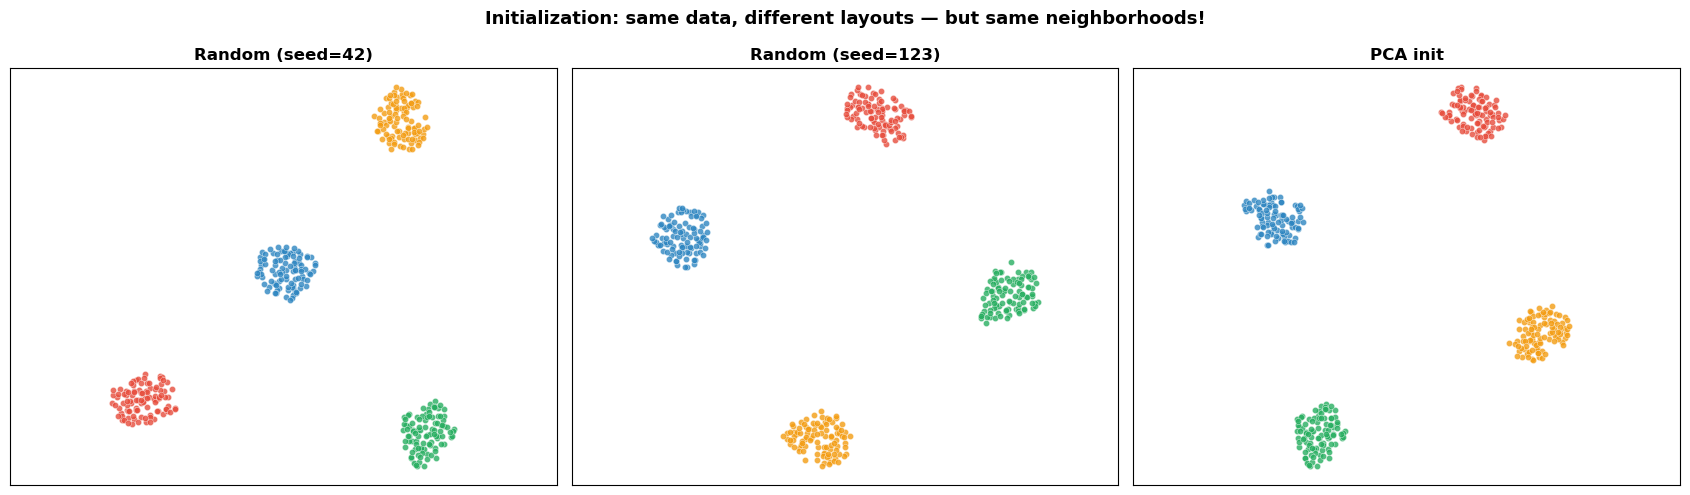

The NEIGHBORHOODS are preserved (same points cluster together)
but the overall layout changes. Axes are meaningless!


In [49]:
# ── Section 4c: Initialization Comparison ──

X_init, labels_init, _ = make_dataset("blobs", n=400, random_state=42)
X_init = StandardScaler().fit_transform(X_init)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
configs = [("random", 42, "Random (seed=42)"),
           ("random", 123, "Random (seed=123)"),
           ("pca", 42, "PCA init")]

for idx, (init, seed, title) in enumerate(configs):
    Y = run_tsne(X_init, perplexity=30, init=init, seed=seed)
    for c, col in enumerate([COLORS["A"], COLORS["B"], COLORS["C"], COLORS["D"]]):
        mask = labels_init == c
        axes[idx].scatter(Y[mask, 0], Y[mask, 1], c=col, s=20, alpha=0.8,
                          edgecolors="white", linewidth=0.3)
    axes[idx].set_title(title, fontsize=12, fontweight="bold")
    axes[idx].grid(True, alpha=0.15)
    axes[idx].set_aspect("equal", adjustable="datalim")
    axes[idx].set_xticks([]); axes[idx].set_yticks([])

plt.suptitle("Initialization: same data, different layouts — but same neighborhoods!",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("The NEIGHBORHOODS are preserved (same points cluster together)")
print("but the overall layout changes. Axes are meaningless!")


---
# Section 5 — How to Use t-SNE in Practice

## Pipeline
1. **Preprocess:** handle missing values, scale features (z-score)
2. **Optional PCA:** reduce to 30–50 dims (denoise, speed up)
3. **Run t-SNE:** sweep perplexity and seeds
4. **Overlay labels** for sanity checking
5. **Report** all parameters for reproducibility

👇 See the effects of scaling and PCA preprocessing.


In [50]:
# ── Section 5a: Scaling Matters ──

def demo_scaling(scale_data=True):
    np.random.seed(42)
    X_base, labels = make_blobs(n_samples=300, centers=3, n_features=5, random_state=42)
    X_unscaled = X_base.copy()
    X_unscaled[:, 0] *= 100  # feature 0 dominates

    X_use = StandardScaler().fit_transform(X_unscaled) if scale_data else X_unscaled
    title = "After z-score scaling" if scale_data else "NO scaling (feature 0 has 100x variance)"

    Y = run_tsne(X_use, perplexity=30, seed=42)

    fig, ax = plt.subplots(figsize=(7, 6))
    for c, col in enumerate([COLORS["A"], COLORS["B"], COLORS["C"]]):
        mask = labels == c
        ax.scatter(Y[mask, 0], Y[mask, 1], c=col, s=30, alpha=0.8,
                   edgecolors="white", linewidth=0.3, label=f"Cluster {c+1}")
    ax.set_title(f"t-SNE: {title}", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10); ax.grid(True, alpha=0.15)
    ax.set_aspect("equal", adjustable="datalim")
    plt.tight_layout()
    plt.show()

    if not scale_data:
        print("Without scaling, feature 0 dominates ALL distances!")
    else:
        print("After scaling, all features contribute equally.")

interact(demo_scaling,
         scale_data=widgets.Checkbox(value=True, description="Scale data (z-score)"))


interactive(children=(Checkbox(value=True, description='Scale data (z-score)'), Output()), _dom_classes=('widg…

<function __main__.demo_scaling(scale_data=True)>

In [51]:
# ── Section 5b: PCA Before t-SNE ──

def demo_pca_before(n_pca=50):
    np.random.seed(42)
    X, labels = make_blobs(n_samples=400, centers=4, n_features=100, cluster_std=2.0, random_state=42)
    X = np.hstack([X, np.random.randn(400, 100) * 0.5])  # 200D
    X = StandardScaler().fit_transform(X)

    n_comp = min(n_pca, X.shape[1])
    t0 = time.time()
    if n_comp < X.shape[1]:
        pca = PCA(n_components=n_comp)
        X_r = pca.fit_transform(X)
        var_ret = pca.explained_variance_ratio_.sum() * 100
    else:
        X_r = X; var_ret = 100.0
    Y = run_tsne(X_r, perplexity=30, seed=42)
    elapsed = time.time() - t0

    fig, ax = plt.subplots(figsize=(7, 6))
    for c, col in enumerate([COLORS["A"], COLORS["B"], COLORS["C"], COLORS["D"]]):
        mask = labels == c
        ax.scatter(Y[mask, 0], Y[mask, 1], c=col, s=25, alpha=0.8,
                   edgecolors="white", linewidth=0.3, label=f"Cluster {c+1}")
    ax.set_title(f"PCA({n_comp}) -> t-SNE | {var_ret:.1f}% var | {elapsed:.2f}s",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.15)
    ax.set_aspect("equal", adjustable="datalim")
    plt.tight_layout()
    plt.show()

interact(demo_pca_before,
         n_pca=widgets.SelectionSlider(options=[5, 10, 20, 30, 50, 100, 200],
                                       value=50, description="PCA dims:"))


interactive(children=(SelectionSlider(description='PCA dims:', index=4, options=(5, 10, 20, 30, 50, 100, 200),…

<function __main__.demo_pca_before(n_pca=50)>

  REUSABLE t-SNE PIPELINE
PCA: 50D -> 30D, variance: 99.1%
KL divergence: 0.7763


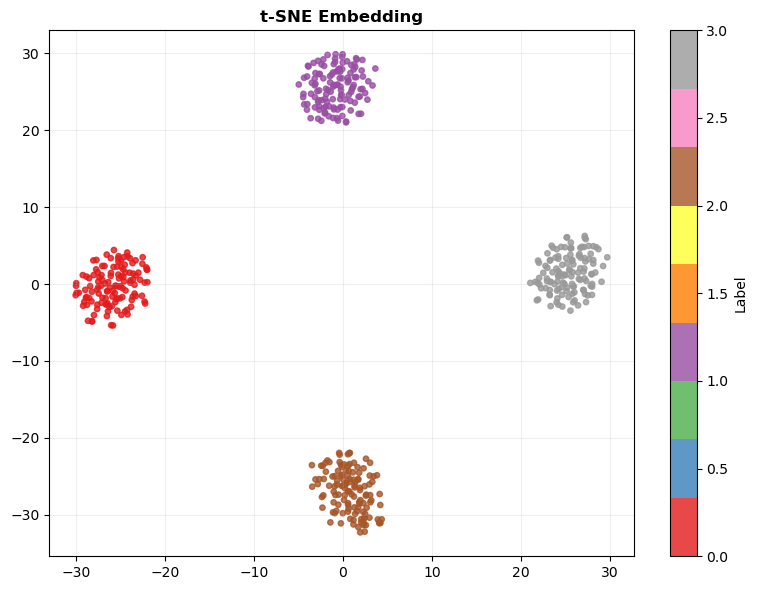


-- Reproducibility Report --
  Preprocessing: StandardScaler + PCA(30)
  Perplexity: 30
  Learning rate: 200
  Early exaggeration: 12
  Iterations: 1000
  Init: pca, Seed: 42
  KL: 0.7763


In [52]:

# ── Section 5c: Reusable Pipeline (COPY THIS) ──

print("=" * 65)
print("  REUSABLE t-SNE PIPELINE")
print("=" * 65)

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np, matplotlib.pyplot as plt

X_demo, y_demo = make_blobs(n_samples=500, centers=4, n_features=50, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_demo)

pca = PCA(n_components=30)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA: {X_scaled.shape[1]}D -> {X_pca.shape[1]}D, "
      f"variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000,
            init="pca", random_state=42, early_exaggeration=12)
X_tsne = tsne.fit_transform(X_pca)
print(f"KL divergence: {tsne.kl_divergence_:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_demo, cmap="Set1", s=15, alpha=0.8)
ax.set_title("t-SNE Embedding", fontweight="bold")
plt.colorbar(scatter, ax=ax, label="Label")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("\n-- Reproducibility Report --")
print(f"  Preprocessing: StandardScaler + PCA({pca.n_components_})")
print(f"  Perplexity: {tsne.perplexity}")
print(f"  Learning rate: {tsne.learning_rate}")
print(f"  Early exaggeration: {tsne.early_exaggeration}")
print(f"  Iterations: {tsne.max_iter}")
print(f"  Init: {tsne.init}, Seed: {tsne.random_state}")
print(f"  KL: {tsne.kl_divergence_:.4f}")


---
# Section 6 — Interpretation & Common Pitfalls

## The 5 pitfalls
1. **Axes are meaningless** — rotation, reflection don't change the objective
2. **Global distances not trustworthy** — inter-cluster spacing is arbitrary
3. **Cluster sizes distorted** — apparent area ≠ population
4. **Apparent clusters can be artifacts** — continuous data can fragment
5. **Tuning to look nice = confirmation bias**

👇 Explore each pitfall interactively.


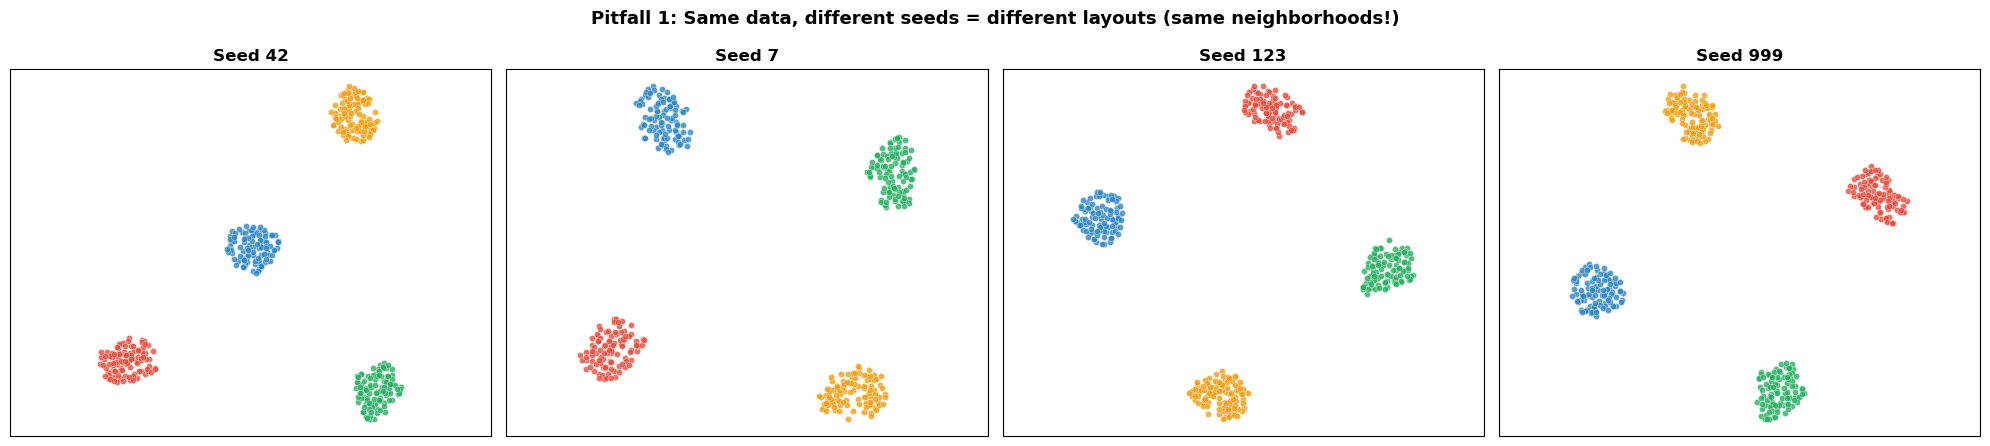

Same points cluster together, but layout rotates/flips. Never interpret axis directions!


In [53]:
# ── Pitfall 1: Axes are Meaningless ──

X_ax, labels_ax, _ = make_dataset("blobs", n=400, random_state=42)
X_ax = StandardScaler().fit_transform(X_ax)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for idx, seed in enumerate([42, 7, 123, 999]):
    Y = run_tsne(X_ax, perplexity=30, seed=seed)
    for c, col in enumerate([COLORS["A"], COLORS["B"], COLORS["C"], COLORS["D"]]):
        mask = labels_ax == c
        axes[idx].scatter(Y[mask, 0], Y[mask, 1], c=col, s=20, alpha=0.8,
                          edgecolors="white", linewidth=0.3)
    axes[idx].set_title(f"Seed {seed}", fontweight="bold")
    axes[idx].set_xticks([]); axes[idx].set_yticks([])
    axes[idx].set_aspect("equal", adjustable="datalim")

plt.suptitle("Pitfall 1: Same data, different seeds = different layouts (same neighborhoods!)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("Same points cluster together, but layout rotates/flips. Never interpret axis directions!")


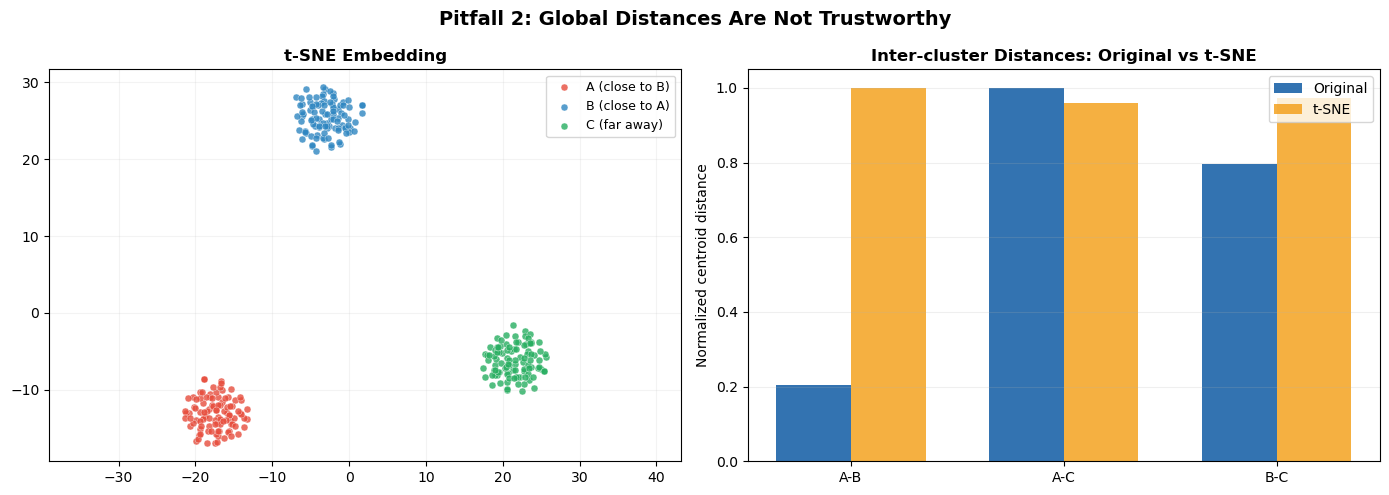

The RATIOS of distances change! t-SNE may show equal spacing
even though C was much farther in the original space.


In [54]:
# ── Pitfall 2: Global Distances Not Trustworthy ──

np.random.seed(42)
n_per = 100
A = np.random.randn(n_per, 10) * 0.8
B = np.random.randn(n_per, 10) * 0.8 + 2   # close to A
C = np.random.randn(n_per, 10) * 0.8 + 10  # far from both
X_gd = StandardScaler().fit_transform(np.vstack([A, B, C]))
labels_gd = np.repeat([0, 1, 2], n_per)

centroids_orig = np.array([X_gd[labels_gd == k].mean(0) for k in range(3)])
d_orig = [np.linalg.norm(centroids_orig[i] - centroids_orig[j])
          for i, j in [(0,1), (0,2), (1,2)]]

Y_gd = run_tsne(X_gd, perplexity=30, seed=42)
centroids_emb = np.array([Y_gd[labels_gd == k].mean(0) for k in range(3)])
d_emb = [np.linalg.norm(centroids_emb[i] - centroids_emb[j])
         for i, j in [(0,1), (0,2), (1,2)]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_3 = [COLORS["A"], COLORS["B"], COLORS["C"]]
names_3 = ["A (close to B)", "B (close to A)", "C (far away)"]
for k in range(3):
    mask = labels_gd == k
    axes[0].scatter(Y_gd[mask, 0], Y_gd[mask, 1], c=colors_3[k], s=25, alpha=0.8,
                    edgecolors="white", linewidth=0.3, label=names_3[k])
axes[0].set_title("t-SNE Embedding", fontweight="bold")
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.15)
axes[0].set_aspect("equal", adjustable="datalim")

x_pos = np.arange(3)
o_n = [d / max(d_orig) for d in d_orig]
e_n = [d / max(d_emb) for d in d_emb]
w = 0.35
axes[1].bar(x_pos - w/2, o_n, w, label="Original", color=COLORS["ntnu"], alpha=0.8)
axes[1].bar(x_pos + w/2, e_n, w, label="t-SNE", color=COLORS["D"], alpha=0.8)
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(["A-B", "A-C", "B-C"])
axes[1].set_ylabel("Normalized centroid distance")
axes[1].set_title("Inter-cluster Distances: Original vs t-SNE", fontweight="bold")
axes[1].legend(); axes[1].grid(True, alpha=0.2, axis="y")

plt.suptitle("Pitfall 2: Global Distances Are Not Trustworthy", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print("The RATIOS of distances change! t-SNE may show equal spacing")
print("even though C was much farther in the original space.")


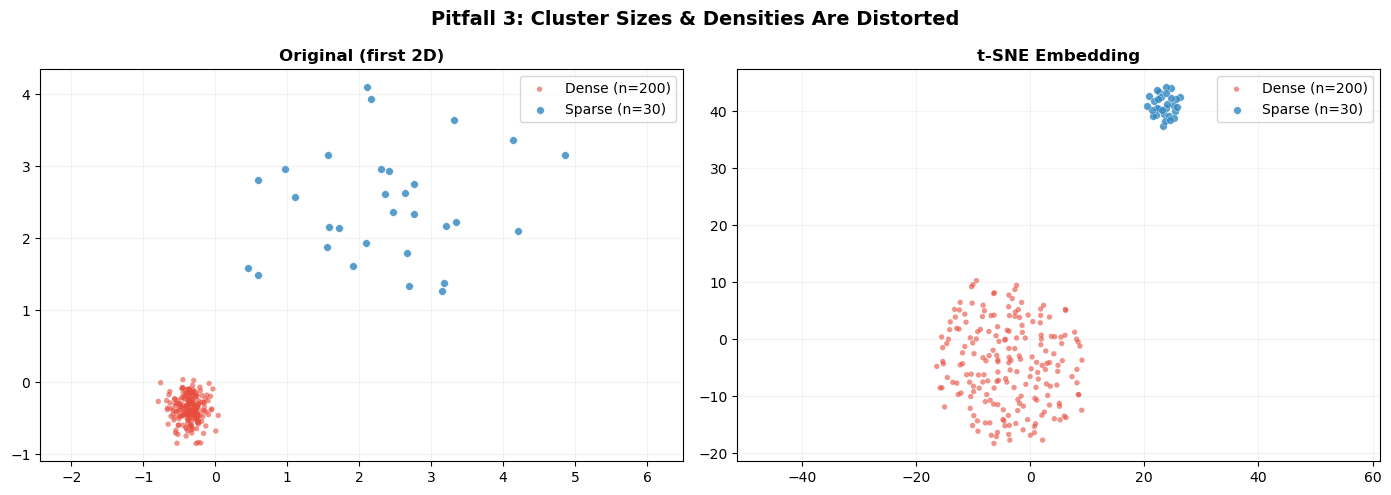

The sparse cluster (n=30) appears similar in size to the dense cluster (n=200)!


In [55]:
# ── Pitfall 3: Density Distortion ──

np.random.seed(42)
dense = np.random.randn(200, 10) * 0.3
sparse = np.random.randn(30, 10) * 2.0 + 5
X_dd = StandardScaler().fit_transform(np.vstack([dense, sparse]))
labels_dd = np.array([0]*200 + [1]*30)

Y_dd = run_tsne(X_dd, perplexity=20, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title in [(axes[0], X_dd, "Original (first 2D)"),
                         (axes[1], Y_dd, "t-SNE Embedding")]:
    ax.scatter(data[labels_dd==0, 0], data[labels_dd==0, 1], c=COLORS["A"], s=15,
               alpha=0.6, label="Dense (n=200)", edgecolors="none")
    ax.scatter(data[labels_dd==1, 0], data[labels_dd==1, 1], c=COLORS["B"], s=30,
               alpha=0.8, label="Sparse (n=30)", edgecolors="white", linewidth=0.3)
    ax.set_title(title, fontweight="bold"); ax.legend(); ax.grid(True, alpha=0.15)
    ax.set_aspect("equal", adjustable="datalim")

plt.suptitle("Pitfall 3: Cluster Sizes & Densities Are Distorted", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print("The sparse cluster (n=30) appears similar in size to the dense cluster (n=200)!")


In [56]:
# ── Pitfall 4: Continuous Data Can Fragment ──

def demo_fragmentation(perplexity=5):
    np.random.seed(42)
    n = 300
    t = np.linspace(0, 1, n)
    X_frag = np.column_stack(
        [t] + [np.sin(2*np.pi*t*k) * 0.3 for k in range(1, 10)]
        + [np.random.randn(n) * 0.05 for _ in range(10)])

    Y = run_tsne(X_frag, perplexity=perplexity, seed=42)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(X_frag[:, 0], X_frag[:, 1], c=t, cmap=CONTINUOUS_CMAP, s=20, alpha=0.8)
    axes[0].set_title("Original: CONTINUOUS gradient", fontweight="bold")

    sc = axes[1].scatter(Y[:, 0], Y[:, 1], c=t, cmap=CONTINUOUS_CMAP, s=20, alpha=0.8)
    axes[1].set_title(f"t-SNE (perplexity={perplexity})", fontweight="bold")
    axes[1].set_aspect("equal", adjustable="datalim")
    plt.colorbar(sc, ax=axes[1], label="Position on line")

    for ax in axes: ax.grid(True, alpha=0.15)
    plt.suptitle("Pitfall 4: Continuous Data Can Fragment", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    if perplexity <= 10:
        print(f"At perplexity={perplexity}, continuous data fragments into ARTIFICIAL islands!")
    else:
        print(f"At perplexity={perplexity}, the continuous structure is better preserved.")

interact(demo_fragmentation,
         perplexity=widgets.SelectionSlider(options=[2, 5, 10, 20, 30, 50, 80],
                                            value=5, description="Perplexity:"))


interactive(children=(SelectionSlider(description='Perplexity:', index=1, options=(2, 5, 10, 20, 30, 50, 80), …

<function __main__.demo_fragmentation(perplexity=5)>

In [57]:
# ── Sanity Check: k-NN Overlap ──

def demo_knn_overlap(k=10, perplexity=30):
    X, labels, _ = make_dataset("blobs", n=400, random_state=42)
    X = StandardScaler().fit_transform(X)
    Y = run_tsne(X, perplexity=perplexity, seed=42)

    nn_hd = NearestNeighbors(n_neighbors=k+1).fit(X)
    _, idx_hd = nn_hd.kneighbors(X)
    idx_hd = idx_hd[:, 1:]

    nn_em = NearestNeighbors(n_neighbors=k+1).fit(Y)
    _, idx_em = nn_em.kneighbors(Y)
    idx_em = idx_em[:, 1:]

    jaccards = np.array([len(set(idx_hd[i]) & set(idx_em[i])) /
                         len(set(idx_hd[i]) | set(idx_em[i])) for i in range(len(X))])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(jaccards, bins=25, color=COLORS["ntnu"], alpha=0.8, edgecolor="white")
    axes[0].axvline(jaccards.mean(), color=COLORS["A"], lw=2, ls="--",
                    label=f"Mean = {jaccards.mean():.3f}")
    axes[0].set_xlabel("Jaccard Overlap"); axes[0].set_ylabel("Count")
    axes[0].set_title(f"k-NN Overlap (k={k}, perp={perplexity})", fontweight="bold")
    axes[0].legend(); axes[0].set_xlim(0, 1)

    sc = axes[1].scatter(Y[:, 0], Y[:, 1], c=jaccards, cmap="RdYlGn", s=25,
                         alpha=0.8, vmin=0, vmax=1)
    axes[1].set_title("Colored by overlap quality", fontweight="bold")
    axes[1].set_aspect("equal", adjustable="datalim"); axes[1].grid(True, alpha=0.15)
    plt.colorbar(sc, ax=axes[1], label="Jaccard overlap")

    plt.tight_layout()
    plt.show()

    q = "good" if jaccards.mean() > 0.5 else "moderate" if jaccards.mean() > 0.3 else "low"
    print(f"Average Jaccard overlap: {jaccards.mean():.3f} ({q})")

interact(demo_knn_overlap,
         k=widgets.IntSlider(min=5, max=50, step=5, value=10, description="k:"),
         perplexity=widgets.SelectionSlider(options=[5, 10, 20, 30, 50, 80],
                                            value=30, description="Perplexity:"))


interactive(children=(IntSlider(value=10, description='k:', max=50, min=5, step=5), SelectionSlider(descriptio…

<function __main__.demo_knn_overlap(k=10, perplexity=30)>

---
# Section 7 — Alternatives and Wrap-Up

| Method | Preserves | Speed | Key parameter |
|--------|-----------|-------|---------------|
| PCA | Global variance | Fast | # components |
| MDS | Pairwise distances | Slow | stress function |
| t-SNE | Local neighborhoods | Moderate | perplexity |
| UMAP | Local + some global | Fast | n_neighbors, min_dist |

👇 Compare all four methods on the same dataset.


In [58]:
# ── Section 7a: Method Comparison Dashboard ──

def demo_comparison(dataset="blobs", n_points=400):
    X, color, title = make_dataset(dataset, n=n_points, random_state=42)
    X_s = StandardScaler().fit_transform(X)
    is_cont = not np.array_equal(color, color.astype(int))
    cmap = CONTINUOUS_CMAP if is_cont else CLUSTER_CMAP

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # PCA
    Y_pca = PCA(n_components=2).fit_transform(X_s)
    axes[0,0].scatter(Y_pca[:,0], Y_pca[:,1], c=color, cmap=cmap, s=15, alpha=0.7)
    axes[0,0].set_title("PCA", fontweight="bold")

    # MDS
    t0 = time.time()
    Y_mds = MDS(n_components=2, random_state=42, normalized_stress="auto").fit_transform(X_s)
    axes[0,1].scatter(Y_mds[:,0], Y_mds[:,1], c=color, cmap=cmap, s=15, alpha=0.7)
    axes[0,1].set_title(f"MDS ({time.time()-t0:.1f}s)", fontweight="bold")

    # t-SNE
    t0 = time.time()
    Y_tsne = run_tsne(X_s, perplexity=30, seed=42)
    axes[1,0].scatter(Y_tsne[:,0], Y_tsne[:,1], c=color, cmap=cmap, s=15, alpha=0.7)
    axes[1,0].set_title(f"t-SNE ({time.time()-t0:.1f}s)", fontweight="bold")

    # UMAP
    try:
        import umap
        t0 = time.time()
        Y_umap = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_s)
        axes[1,1].scatter(Y_umap[:,0], Y_umap[:,1], c=color, cmap=cmap, s=15, alpha=0.7)
        axes[1,1].set_title(f"UMAP ({time.time()-t0:.1f}s)", fontweight="bold")
    except ImportError:
        axes[1,1].text(0.5, 0.5, "UMAP not installed", transform=axes[1,1].transAxes,
                       ha="center", va="center", fontsize=14)
        axes[1,1].set_title("UMAP (N/A)", fontweight="bold")

    for ax in axes.flat:
        ax.set_aspect("equal", adjustable="datalim")
        ax.grid(True, alpha=0.15); ax.set_xticks([]); ax.set_yticks([])

    plt.suptitle(f"Method Comparison: {title}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

interact(demo_comparison,
         dataset=widgets.Dropdown(options=["blobs", "swiss_roll", "s_curve", "moons", "concentric"],
                                  value="swiss_roll", description="Dataset:"),
         n_points=widgets.IntSlider(min=200, max=800, step=100, value=400, description="N:"))


interactive(children=(Dropdown(description='Dataset:', index=1, options=('blobs', 'swiss_roll', 's_curve', 'mo…

<function __main__.demo_comparison(dataset='blobs', n_points=400)>

In [59]:
# ── Section 7b: UMAP Parameter Explorer ──

def demo_umap(n_neighbors=15, min_dist=0.1):
    try:
        import umap
    except ImportError:
        print("UMAP not installed. Run: pip install umap-learn")
        return

    X, labels, _ = make_dataset("blobs", n=400, random_state=42)
    X = StandardScaler().fit_transform(X)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    Y_t = run_tsne(X, perplexity=n_neighbors, seed=42)
    Y_u = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, random_state=42).fit_transform(X)

    for ax, Y, title in [(axes[0], Y_t, f"t-SNE (perp={n_neighbors})"),
                          (axes[1], Y_u, f"UMAP (nn={n_neighbors}, md={min_dist})")]:
        for c, col in enumerate([COLORS["A"], COLORS["B"], COLORS["C"], COLORS["D"]]):
            mask = labels == c
            ax.scatter(Y[mask,0], Y[mask,1], c=col, s=20, alpha=0.8,
                       edgecolors="white", linewidth=0.3)
        ax.set_title(title, fontweight="bold"); ax.grid(True, alpha=0.15)
        ax.set_aspect("equal", adjustable="datalim"); ax.set_xticks([]); ax.set_yticks([])

    plt.suptitle("t-SNE vs UMAP", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

interact(demo_umap,
         n_neighbors=widgets.IntSlider(min=2, max=100, value=15, description="n_neighbors:"),
         min_dist=widgets.FloatSlider(min=0.0, max=1.0, step=0.05, value=0.1, description="min_dist:"))


interactive(children=(IntSlider(value=15, description='n_neighbors:', min=2), FloatSlider(value=0.1, descripti…

<function __main__.demo_umap(n_neighbors=15, min_dist=0.1)>

---
# Bonus: t-SNE on Real Data (MNIST Digits)

The classic MNIST handwritten digits — 64 features (8x8 pixel images), 1797 samples.


In [60]:

# ── Bonus: MNIST ──

print("Loading digits dataset...")
digits = load_digits()
X_d = StandardScaler().fit_transform(digits.data)
X_d_pca = PCA(n_components=30).fit_transform(X_d)

print("Running t-SNE...")
Y_d = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000,
           init="pca", random_state=42).fit_transform(X_d_pca)
print("Done!")

fig = go.Figure()
colors_10 = px.colors.qualitative.G10  # exactly 10 colors
for digit in range(10):
    mask = digits.target == digit
    fig.add_trace(go.Scatter(
        x=Y_d[mask, 0], y=Y_d[mask, 1], mode="markers",
        name=f"Digit {digit}",
        marker=dict(size=5, color=colors_10[digit], opacity=0.7),
        text=[f"Digit {digit}"] * mask.sum(), hoverinfo="text"))

fig.update_layout(title="t-SNE of Handwritten Digits (hover to explore!)",
                  xaxis_title="t-SNE 1", yaxis_title="t-SNE 2",
                  width=800, height=600, template="plotly_white")
fig.show()

print("Hover over points to see labels. Zoom into boundary regions (e.g., 4 vs 9).")
print("Click legend entries to toggle digits on/off.")


Loading digits dataset...
Running t-SNE...
Done!


Hover over points to see labels. Zoom into boundary regions (e.g., 4 vs 9).
Click legend entries to toggle digits on/off.


---
# Summary: The 5 Rules of Thumb

1. **Scale features** — distances drive neighborhoods
2. **Try PCA first** — optionally PCA before t-SNE
3. **Sweep perplexity and seeds** — check stability
4. **Interpret locally** — avoid global distance claims
5. **Validate** — with metadata, labels, and alternative methods

---

### What to trust

| ✅ Trust | ❌ Don't trust |
|----------|---------------|
| Local mixing vs separation | Distance between far clusters |
| Smooth gradients within neighborhoods | Cluster area or shape |
| Presence of outliers | Axis directions |
| Consistent patterns across seeds | Single-run artifacts |

---

*End of interactive t-SNE exploration notebook.*
